# 04 — Evaluation



Model against the frozen baselines: NDCG@10 with bootstrap CIs on a sealed fold, per-city and

group-size breakdowns, the hyperparameter search, and what none of it can be claimed to mean.

## The conclusion, stated up front

**The model beats both frozen baselines by a margin that is large relative to its interval, it is
not a re-derivation of Phase 1, and tuning added nothing to it.** On the holdout — fold 0, 72
query groups, read twice in the project's history and now closed — NDCG@10 is **0.7530**
[0.7148, 0.7903] against review-count **0.6390**, price+rating **0.6429** and a random floor of
**0.5519**. Paired against review-count that is **+0.1139** [0.0795, 0.1534].

Five things make that safe to quote, and two cap what it means.

1. **It is not leakage.** Grades shuffled *within* query group collapse the model to the floor
   (§4), while the real-label control at the same 500 trees scores 0.7541.
2. **It is not establishment re-derived.** A model denied all 8 establishment features still
   reaches 0.7031; one given only them reaches 0.6660 (§7).
3. **It is not a lucky test half.** The development out-of-fold estimate, a different object on
   311 different groups, agrees: 0.7209, paired +0.0776 [0.0594, 0.0938].
4. **It is not tuned.** A 35-configuration search promised +0.0142 out-of-fold and delivered
   **−0.0016** on the holdout (§9). The winner's curse, observed rather than argued.
5. **It is stable across seeds** where there are enough groups to say so: sd 0.0036 overall,
   against 0.0395 for Thessaloniki's four groups (§9).

**What caps it.** The target is `blocked_fraction_90` — forward calendar *availability*, not
demand. And the model **buries never-reviewed listings below where the target itself places
them**, surfacing the deserving ones into a top 10 less often than a random ranker would (§8).
The group-level metric cannot see that at all.

## 0. The frame



Everything below is recomputed from `src` — the notebook holds no logic of its own. `train.run`

executes the whole protocol: the component split, four-fold cross-validation on the development

pool, the refit, and the single sealed-fold read. It takes a few minutes.



The hyperparameter search is the one exception. It costs 35 cross-validations, so its results

table is read from `data/train/sweep_results.csv`, rebuilt by

`uv run python -m rental_ranking.train.train --sweep 35`.

In [1]:
import numpy as np
import pandas as pd

from rental_ranking.data.paths import (
    FEATURE_TABLE_PATH,
    SWEEP_RESULTS_PATH,
    TRAIN_DIR,
)
from rental_ranking.evaluate.metrics import ndcg_at_k
from rental_ranking.evaluate.report import headline, paired_difference, random_floor
from rental_ranking.train import baseline as bl
from rental_ranking.train import lambdamart as lm
from rental_ranking.train import split, sweep
from rental_ranking.train import train as trainer

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

CITIES = ["thessaloniki", "athens", "crete"]

table = pd.read_parquet(FEATURE_TABLE_PATH)
print(f"{len(table):,} listings x {table.shape[1]} columns, {table['query_group'].nunique()} query groups")

/Users/fotisn/code/repos/airbnb_rec/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


44,684 listings x 66 columns, 393 query groups


## 1. The split, and the conflict it had to resolve



**What the table below shows.** The five folds: rows, query groups, split components and the

median group size in each. Fold 0 is the sealed test half.



Two constraints wanted the same rows. Near-twin listings — same host, same point, same capacity —

must not straddle the split, or the model memorises the pair. Query groups must not be broken, or

NDCG on the test half is computed over a partial candidate set and is no longer the measurement

the frozen baselines made. But **76 clusters span more than one query group**, so neither holds

alone.



The resolution is to split on the **connected components** of the `cluster_id` x `query_group`

graph, which are the coarsest units both constraints respect exactly.

In [2]:
fold, fold_report = split.assign_folds(table)

component = split.split_component(table)



print(f"{component.nunique()} split components over {table['query_group'].nunique()} query groups "

      f"and {table['cluster_id'].nunique():,} clusters")

print(f"largest component: {component.value_counts().iloc[0]:,} rows "

      f"({component.value_counts().iloc[0] / len(table):.1%} of the population)")

fold_report.round(4)

345 split components over 393 query groups and 41,148 clusters
largest component: 2,240 rows (5.0% of the population)


,rows,row_share,groups,components,clusters,median_group_size
fold,,,,,,
0,8946,0.2002,74,66,8281,28.0
1,8944,0.2002,79,70,8288,28.0
2,8945,0.2002,77,67,8516,30.0
3,8927,0.1998,84,73,7937,29.0
4,8922,0.1997,79,69,8126,26.0


**Option A cost almost nothing, and the reason is worth stating.** 345 components; 305 hold one

query group, 32 hold two, 8 hold three; none crosses a city. The largest holds 5.0 % of rows,

which brushes the roadmap's abort threshold and reads worse than it is: **the lumpiness comes

from the group-size skew, not from the components.** The largest single query group is already

2,088 rows, and the top-five unit sizes barely move under the coarsening —

`2088 2042 1411 1160 1114` as groups against `2240 2135 1411 1305 1247` as components.



So both constraints hold exactly, no listing is dropped and no group is broken. The two

alternatives — accepting 88 partially evaluated groups, or accepting 253 listings of twin leakage

— were paying a real price to avoid a cost that is not there.

**What the tables below show.** What each fold carries: cities and group-size bands counted in

*query groups* (the unit the metric averages over), and grades counted in rows.



Folds are balanced on rows and stratified on city **and group-size band**. The band is the

addition, and it matters more than the city: per-group NDCG for the review-count baseline runs

`0.824 / 0.642 / 0.545 / 0.576 / 0.646` across the bands, a 0.28 spread that swamps anything a

model will do. A test half drawn heavy in small groups scores higher for *every* ranker in the

table.



Band is a pre-label structural property, so balancing on it is not conditioning on the target.

**Grade is, and the objective never reads it** — it is reported here and never optimised.

In [3]:
band = split.group_size_band(table)

display(split.fold_balance(fold, table["city"], table["query_group"]).round(4))

display(split.fold_balance(fold, band, table["query_group"]).round(4))

display(split.fold_balance(fold, table["grade"]).round(4))

value,athens,crete,thessaloniki
fold,,,
0,0.5135,0.4324,0.0541
1,0.5063,0.4177,0.0759
2,0.4935,0.4286,0.0779
3,0.5000,0.4048,0.0952
4,0.5063,0.4177,0.0759


value,<10,10-30,30-100,100-400,400+
fold,,,,,
0,0.2568,0.2568,0.2297,0.1757,0.0811
1,0.2532,0.2658,0.2405,0.1646,0.0759
2,0.2597,0.2468,0.2338,0.1688,0.0909
3,0.2500,0.2619,0.2381,0.1786,0.0714
4,0.2658,0.2658,0.2278,0.1646,0.0759


value,0,1,2,3,4
fold,,,,,
0,0.0249,0.2326,0.2448,0.2524,0.2452
1,0.0401,0.2714,0.2462,0.2219,0.2204
2,0.0292,0.2253,0.2388,0.2596,0.2472
3,0.0344,0.2332,0.2377,0.2509,0.2438
4,0.0408,0.2698,0.2399,0.2344,0.2152


**Grade balance came out unforced at 21.5–24.5 % in the top class**, which is the point: it was

not an objective. City shares sit within 4 pp and band shares within 1.6 pp of the population.



The visible weakness is Thessaloniki. It has **30 query groups in total**, so a fifth of them is

four — and §5 shows why that makes a per-city claim from the sealed fold impossible.

## 2. Why a single test half was not enough



**What the table below shows.** Baseline A minus baseline B — a **constant**, since neither is

fitted and neither reads the label — read off each of the five folds in turn as if it were the

test half.

In [4]:


group_fold = fold.groupby(table["query_group"], observed=True).first()

na = ndcg_at_k(table["grade"], table["query_group"], bl.rank_by_reviews(table))

nb = ndcg_at_k(table["grade"], table["query_group"], bl.rank_by_price_and_rating(table, table["query_group"]))



rows = []

for k in sorted(fold.unique()):

    index = na.index.intersection(group_fold.index[group_fold.eq(k)])

    rows.append({

        "fold": k,

        "groups": int(na.loc[index].notna().sum()),

        "reviews": na.loc[index].mean(),

        "price_rating": nb.loc[index].mean(),

        "A - B": (na - nb).loc[index].mean(),

    })

rows.append({"fold": "population", "groups": int(na.notna().sum()), "reviews": na.mean(),

             "price_rating": nb.mean(), "A - B": (na - nb).mean()})

pd.DataFrame(rows).set_index("fold").round(4)

,groups,reviews,price_rating,A - B
fold,,,,
0,72,0.6390,0.6429,-0.0038
1,77,0.6297,0.6080,0.0217
2,75,0.6723,0.6238,0.0485
3,83,0.6351,0.6190,0.0162
4,76,0.6371,0.6168,0.0203
population,383,0.6424,0.6218,0.0207


**A constant reads anywhere from 0.005 to 0.049 depending on which fold you happen to call the

test half.** Its true value is 0.0207. Per-group NDCG has standard deviation 0.187, so at ~75

groups the 95 % half-width is ±0.041 on a level and ±0.037 paired — the same size as the

model-versus-baseline effect this phase exists to detect.



That is why the protocol is **one sealed fold plus a four-fold development pool**, not 80/20 with

a single validation split. Every decision — the stopping iteration, the hyperparameters in §6 —

is made against ~307 groups instead of one 75-group draw, and the sealed fold stays sealed.



Note also that on this particular sealed fold **the two baselines swap order**: price+rating

0.6429 leads review-count 0.6390, where on the population review-count leads by 0.0207. The

paired interval covers zero, so it is noise — but it is why the model is reported against *both*

baselines below rather than against whichever one it beats more comfortably.

## 3. Training, and what the folds could not pin down



**What the output below shows.** The whole protocol executed: four cross-validation fits on the

development pool, the median stopping iteration, and the refit over five seeds.

In [5]:
tables = trainer.run(log_to_mlflow=False)

feature table  44,684 rows x 61 features -> /Users/fotisn/code/repos/airbnb_rec/data/features/feature_table.parquet



split — sealed fold 0: 8,946 rows; pool: 35,738
      rows  row_share  groups  components  clusters  median_group_size
fold                                                                  
0     8946     0.2002      74          66      8281               28.0
1     8944     0.2002      79          70      8288               28.0
2     8945     0.2002      77          67      8516               30.0
3     8927     0.1998      84          73      7937               29.0
4     8922     0.1997      79          69      8126               26.0

cross-validating on folds 1-4


  cv fold 1/4: stopped at  514 trees, held-out NDCG@10 0.7026 on 77 groups


  cv fold 2/4: stopped at  718 trees, held-out NDCG@10 0.7632 on 75 groups


  cv fold 3/4: stopped at  158 trees, held-out NDCG@10 0.7078 on 83 groups


...

  refit seed 0: 362 trees on 35,738 rows


  refit seed 1: 362 trees on 35,738 rows


  refit seed 2: 362 trees on 35,738 rows


  refit seed 3: 362 trees on 35,738 rows


  refit seed 4: 362 trees on 35,738 rows


**The stopping iteration is barely identified.** The four folds stopped at 514 / 718 / 158 / 211

trees — a **4.5× spread** — while their NDCG stayed inside a 0.06 band. The median, 362, is taken

**unscaled**: scaling by k/(k−1) for the larger training set is folklore, and a number that

uncertain does not deserve a correction factor. The flatness is itself the finding, and it

predicts §6's outcome.



**The five-seed spread is exactly 0.000, and that is not stability.** At these parameters

(`subsample_freq=0`, `colsample_bytree=1.0`) LightGBM is fully deterministic — three seeds give

bit-identical predictions. There is no randomness to average over. The variance that exists is

over *data*, and the bootstrap intervals below are what measure it.

**What the figure below shows.** Validation NDCG@10 against boosting iteration, one line per
development fold, with each fold's chosen stopping point dotted in its own colour and the median
used for the refit in black. This is the evidence for the paragraph above — written as prose,
"the stopping point is barely identified" is an assertion; four curves that flatten by ~100
iterations while their best-iteration markers scatter from 158 to 718 is a measurement.

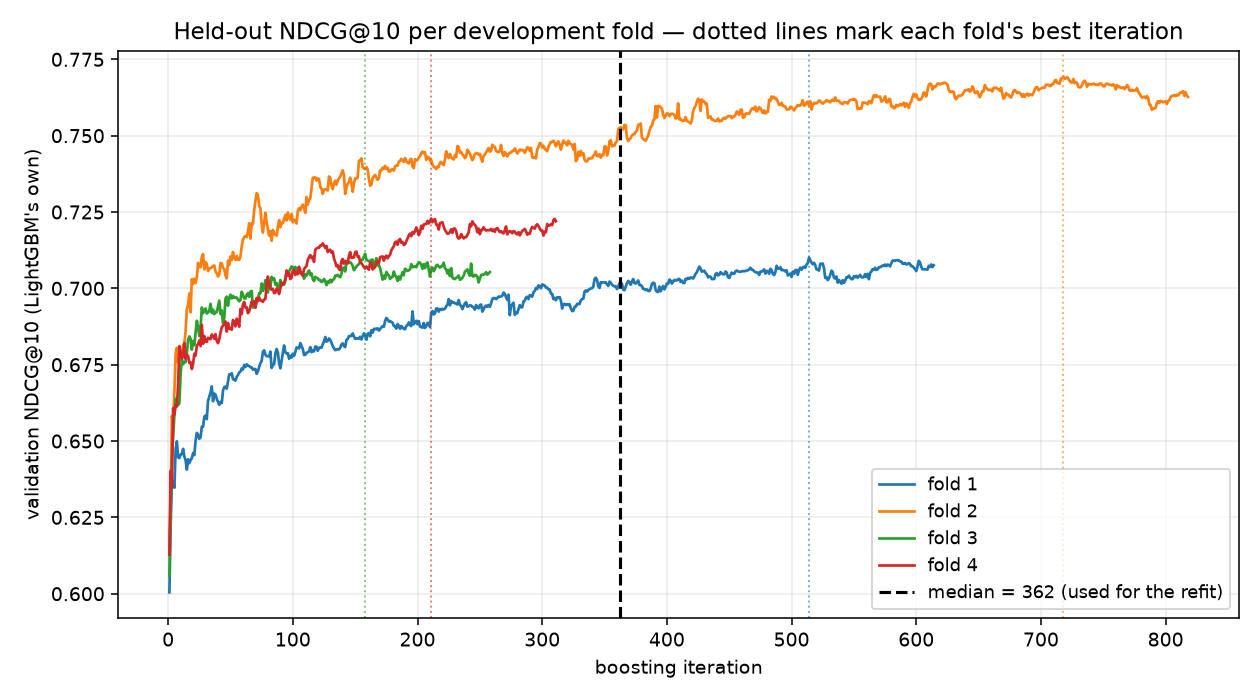

In [6]:
from IPython.display import Image

curve_path = trainer.plot_learning_curves(
    {int(c.split("_")[1]): tables["curves"][c].dropna().tolist() for c in tables["curves"]},
    tables["cv"]["best_iteration"].tolist(),
    TRAIN_DIR / "learning_curves.png",
)
Image(str(curve_path))

**The curves flatten early and then wander.** Every fold is within 0.02 of its final value by
iteration 150, and the markers land wherever noise happened to put a hundred-round patience —
158, 211, 514, 718. The metric is not choosing between those points; it cannot tell them apart.

This figure also predicts §9 before it happens. A 35-configuration hyperparameter search over a
surface this flat was never going to find much, and it did not.

In [7]:
print("stochastic at the default parameters?", lm.is_stochastic({}))

tables["cv"].round(4)

stochastic at the default parameters? False


,train_rows,valid_rows,valid_groups,best_iteration,ndcg@10
fold,,,,,
1,26794,8944,77,514,0.7026
2,26793,8945,75,718,0.7632
3,26811,8927,83,158,0.7078
4,26816,8922,76,211,0.7119


## 4. Is it leakage?



**What the table below shows.** Grades permuted **within** query group — features untouched,

group structure and grade marginals preserved — the model retrained, and the sealed fold scored.

If any path runs from label to features that `check_feature_table`'s blocklist does not name,

a model trained on destroyed labels still beats the floor.



This takes four fits and is the single most important cell in the notebook.

In [8]:
sealed = split.sealed_mask(fold)

development, held_out = table[~sealed], table[sealed]

floor_all = random_floor(table["grade"], table["query_group"])

sealed_floor = floor_all.loc[floor_all.index.intersection(held_out["query_group"].unique())].mean()



rng = np.random.default_rng(0)

rows = []

for trial in range(3):

    shuffled = development.copy()

    shuffled["grade"] = shuffled.groupby("query_group", observed=True)["grade"].transform(

        lambda s: rng.permutation(s.to_numpy())

    )

    model = lm.fit(shuffled, None, seed=0, n_estimators=500)

    scored = ndcg_at_k(held_out["grade"], held_out["query_group"], lm.predict(model, held_out))

    rows.append({"trial": f"permuted {trial}", "sealed ndcg@10": scored.mean()})



control = lm.fit(development, None, seed=0, n_estimators=500)

rows.append({"trial": "real labels", "sealed ndcg@10":

             ndcg_at_k(held_out["grade"], held_out["query_group"], lm.predict(control, held_out)).mean()})

rows.append({"trial": "random floor", "sealed ndcg@10": sealed_floor})

pd.DataFrame(rows).set_index("trial").round(4)

,sealed ndcg@10
trial,
permuted 0,0.5705
permuted 1,0.5926
permuted 2,0.5407
real labels,0.7541
random floor,0.5519


**No structural leak.** The three permuted models straddle the floor; the real-label control at

the same 500 trees scores 0.754. This is a stronger claim than the blocklist check, which only

proves no *named* label column is present — the permutation test also rules out an unnamed path.

## 5. The result



**What the two tables below show.** Every ranker scored on identically the same groups, sliced

the same way, with the random floor recomputed **per slice** and the paired bootstrap difference

against review-count.



The first estimates the **procedure** — a model trained this way on three quarters of the pool,

each group scored by the fold model that held it out. The second estimates the **artifact** — the

model that would ship, on groups nothing in the pipeline has touched. They are different objects

and the distinction is not pedantry: the per-city claim can only come from the first.

In [9]:
display(tables["oof"].round(4))

display(tables["sealed"].round(4))



# The framing was fixed before the number existed: level, both comparators, that

# slice's own floor, and the share of the usable range it traverses. Each baseline

# gets its own table, because a paired interval only exists against its own reference.

for key, base in (("sealed", "reviews"), ("sealed_vs_price_rating", "price_rating")):

    for slice_name in ("overall", "n>10"):

        print(headline(tables[key], "model_seed0", base, slice_name), end="\n\n")

groups  degenerate  ndcg@10  ndcg_low  ndcg_high   floor  range_share  vs_reviews  vs_low  vs_high
slice        ranker                                                                                                          
overall      model_oof        311           8   0.7209    0.7013     0.7398  0.5402       0.3929      0.0776  0.0594   0.0938
             reviews          311           8   0.6432    0.6230     0.6649  0.5402       0.2241      0.0000  0.0000   0.0000
             price_rating     311           8   0.6169    0.5954     0.6392  0.5402       0.1668     -0.0263 -0.0454  -0.0084
n>10         model_oof        237           0   0.6816    0.6623     0.7012  0.4620       0.4082      0.0913  0.0716   0.1126
             reviews          237           0   0.5903    0.5684     0.6116  0.4620       0.2384      0.0000  0.0000   0.0000
             price_rating     237           0   0.5590    0.5364     0.5812  0.4620       0.1803     -0.0313 -0.0532  -0.0090
n<=10        model_oof         74           8   0.8466    0.8157     0.8760  0.7907       0.2673      0.0337 -0.0020   0.0688
             reviews           74           8   0.8129    0.7791     0.8451  0.7907       0.1061      0.0000  0.0000   0.0000
             price_rating      74           8   0.8023    0.7683     0.8336  0.7907       0.0558     -0.0105 -0.0457   0.0226
athens       model_oof        157           3   0.7347    0.7079     0.7600  0.5411       0.4218      0.0933  0.0683   0.1180
             reviews          157           3   0.6413    0.6107     0.6691  0.5411       0.2184      0.0000  0.0000   0.0000
             price_rating     157           3   0.6142    0.5845     0.6438  0.5411       0.1592     -0.0271 -0.0563   0.0003
crete        model_oof        130           3   0.7030    0.6740     0.7320  0.5392       0.3555      0.0598  0.0335   0.0869
             reviews          130           3   0.6432    0.6093     0.6766  0.5392       0.2257      0.0000  0.0000   0.0000
             price_rating     130           3   0.6086    0.5745     0.6427  0.5392       0.1506     -0.0346 -0.0603  -0.0069
thessaloniki model_oof         24           2   0.7273    0.6632     0.7905  0.5395       0.4078      0.0714  0.0100   0.1356
             reviews           24           2   0.6559    0.5867     0.7331  0.5395       0.2528      0.0000  0.0000   0.0000
             price_rating      24           2   0.6796    0.6115     0.7513  0.5395       0.3041      0.0236 -0.0281   0.0766

groups  degenerate  ndcg@10  ndcg_low  ndcg_high   floor  range_share  vs_reviews  vs_low  vs_high
slice        ranker                                                                                                          
overall      model_seed0       72           2   0.7530    0.7148     0.7903  0.5519       0.4487      0.1139  0.0795   0.1534
             model_seed1       72           2   0.7530    0.7148     0.7903  0.5519       0.4487      0.1139  0.0795   0.1534
             model_seed2       72           2   0.7530    0.7148     0.7903  0.5519       0.4487      0.1139  0.0795   0.1534
             model_seed3       72           2   0.7530    0.7148     0.7903  0.5519       0.4487      0.1139  0.0795   0.1534
             model_seed4       72           2   0.7530    0.7148     0.7903  0.5519       0.4487      0.1139  0.0795   0.1534
             reviews           72           2   0.6390    0.5973     0.6786  0.5519       0.1944      0.0000  0.0000   0.0000
             price_rating      72           2   0.6429    0.6030     0.6852  0.5519       0.2030      0.0038 -0.0282   0.0391
n>10         model_seed0       55           0   0.7184    0.6808     0.7582  0.4808       0.4576      0.1233  0.0781   0.1663
             model_seed1       55           0   0.7184    0.6808     0.7582  0.4808       0.4576      0.1233  0.0781   0.1663
             model_seed2       55           0   0.7184    0.6808     0.7582  0.4808       0.4576      0.1233  0.0781   0.1663
             model_seed3       55           0   0.7184    0.6808     0.7582  0.4808       0.4576      0.1233  0.0781   0.1663
             model_seed4       55           0   0.7184    0.6808     0.7582  0.4808       0.4576      0.1233  0.0781   0.1663
             reviews           55           0   0.5951    0.5540     0.6390  0.4808       0.2202      0.0000  0.0000   0.0000
             price_rating      55           0   0.5859    0.5479     0.6258  0.4808       0.2023     -0.0093 -0.0457   0.0288
n<=10        model_seed0       17           2   0.8650    0.7894     0.9309  0.7821       0.3803      0.0838  0.0123   0.1631
             model_seed1       17           2   0.8650    0.7894     0.9309  0.7821       0.3803      0.0838  0.0123   0.1631
             model_seed2       17           2   0.8650    0.7894     0.9309  0.7821       0.3803      0.0838  0.0123   0.1631
             model_seed3       17           2   0.8650    0.7894     0.9309  0.7821       0.3803      0.0838  0.0123   0.1631
             model_seed4       17           2   0.8650    0.7894     0.9309  0.7821       0.3803      0.0838  0.0123   0.1631
             reviews           17           2   0.7811    0.7017     0.8576  0.7821      -0.0044      0.0000  0.0000   0.0000
             price_rating      17           2   0.8273    0.7543     0.8964  0.7821       0.2077      0.0462 -0.0181   0.1157
athens       model_seed0       38           0   0.7488    0.6980     0.8011  0.5647       0.4229      0.0938  0.0462   0.1430
             model_seed1       38           0   0.7488    0.6980     0.8011  0.5647       0.4229      0.0938  0.0462   0.1430
             model_seed2       38           0   0.7488    0.6980     0.8011  0.5647       0.4229      0.0938  0.0462   0.1430
             model_seed3       38           0   0.7488    0.6980     0.8011  0.5647       0.4229      0.0938  0.0462   0.1430
             model_seed4       38           0   0.7488    0.6980     0.8011  0.5647       0.4229      0.0938  0.0462   0.1430
             reviews           38           0   0.6550    0.5984     0.7114  0.5647       0.2075      0.0000  0.0000   0.0000
             price_rating      38           0   0.6484    0.5954     0.7035  0.5647       0.1922     -0.0066 -0.0477   0.0321
crete        model_seed0       30           2   0.7512    0.6970     0.8036  0.5194       0.4824      0.1339  0.0704   0.1992
             model_seed1       30           2   0.7512    0.6970     0.8036  0.5194       0.4824      0.1339  0.0704   0.

NDCG@10 0.7530 [0.7148, 0.7903] against reviews at 0.6390 and a random floor of 0.5519 on 72 groups (overall); the difference is +0.1139 [+0.0795, +0.1534] paired, and it traverses 44.9% of the floor-to-1 range against 19.4% for reviews.

NDCG@10 0.7184 [0.6808, 0.7582] against reviews at 0.5951 and a random floor of 0.4808 on 55 groups (n>10); the difference is +0.1233 [+0.0781, +0.1663] paired, and it traverses 45.8% of the floor-to-1 range against 22.0% for reviews.

NDCG@10 0.7530 [0.7148, 0.7903] against price_rating at 0.6429 and a random floor of 0.5519 on 72 groups (overall); the difference is +0.1101 [+0.0740, +0.1475] paired, and it traverses 44.9% of the floor-to-1 range against 20.3% for price_rating.

NDCG@10 0.7184 [0.6808, 0.7582] against price_rating at 0.5859 and a random floor of 0.4808 on 55 groups (n>10); the difference is +0.1325 [+0.0892, +0.1783] paired, and it traverses 45.8% of the floor-to-1 range against 20.2% for price_rating.



**0.7530 on the sealed fold against 0.6390 and 0.6429, floor 0.5519**, paired **+0.1139**

[0.0795, 0.1534]. It traverses **44.9 %** of the floor-to-1 range where the baseline traverses

19.4 %. The out-of-fold estimate — a different object on 311 different groups — lands at 0.7209,

paired +0.0776 [0.0594, 0.0938]. **The two agreeing matters more than either number.**



**Per city, from the out-of-fold**: Athens 0.7347 (+0.0933), Crete 0.7030 (+0.0598), Thessaloniki

0.7273 (+0.0714 [0.0100, 0.1356]). The model leads in all three and every interval clears zero.



**Thessaloniki is not reportable from the sealed fold, and the reason is worth being precise

about.** It holds 4 groups there, 88 listings. Those 88 listings buy nothing: a group's NDCG is a

*deterministic* function of its rows, so there is no sampling noise inside a group at all. The

uncertainty is entirely between groups, and there are four draws — a 95 % half-width of ±0.183 on

a range 0.458 wide, from a bootstrap with only 35 distinct resamples. 54 groups are needed for

±0.05. The out-of-fold gives 24 and ±0.071.

**What the table below shows.** The same comparison by group-size band — and the check on a

prediction that was written down *before* the model was trained.



Training and evaluation weight this data almost inversely. Rows / label-differing pairs (which is

where LambdaMART's gradient lives) / share of the metric, by band:



| band | rows | pairs | metric |

|---|---|---|---|

| `<10` | 1.55 % | **0.015 %** | 25.7 % |

| 10-30 | 4.34 % | 0.144 % | 26.0 % |

| 30-100 | 11.63 % | 1.202 % | 23.4 % |

| 100-400 | 30.53 % | 11.963 % | 17.0 % |

| 400+ | 51.94 % | **86.677 %** | 7.9 % |



86.7 % of the gradient sits in the 31 groups carrying 7.9 % of the metric. The prediction logged

in advance was: **the model should score best on the largest band and worst on the smallest.**

In [10]:
bands = ["<10", "10-30", "30-100", "100-400", "400+"]

model_rows = tables["oof_band"].xs("model_oof", level="ranker").reindex(bands)

base_rows = tables["oof_band"].xs("reviews", level="ranker").reindex(bands)

pd.DataFrame({

    "groups": model_rows["groups"],

    "floor": model_rows["floor"],

    "baseline": base_rows["ndcg@10"],

    "model": model_rows["ndcg@10"],

    "range_share": model_rows["range_share"],

    "vs_baseline": model_rows["vs_reviews"],

    "vs_low": model_rows["vs_low"],

    "vs_high": model_rows["vs_high"],

}).round(4)

,groups,floor,baseline,model,range_share,vs_baseline,vs_low,vs_high
slice,,,,,,,,
<10,74,0.7907,0.8129,0.8466,0.2673,0.0337,-0.0020,0.0688
10-30,83,0.5568,0.6290,0.6697,0.2549,0.0408,0.0067,0.0742
30-100,75,0.4020,0.5324,0.6378,0.3944,0.1055,0.0716,0.1423
100-400,54,0.4224,0.5732,0.7249,0.5237,0.1517,0.1137,0.1891
400+,25,0.4129,0.6724,0.7588,0.5892,0.0864,0.0332,0.1444


**Confirmed, and only on the right axis.** `range_share` — the share of that band's own

floor-to-1 range — runs `0.267 / 0.255 / 0.394 / 0.524 / 0.589`, monotone above 30 exactly as

predicted. Raw NDCG is **not** monotone, because the floors differ by 0.38 across bands, which is

precisely why the floor is recomputed per slice rather than quoted once.



**In the smallest band the model can barely beat the baseline: +0.0337 with an interval

[-0.0020, 0.0688] that touches zero.** In groups of ten or fewer the cut-off at 10 excludes

nothing, so NDCG@10 scores the whole list and everything reads high — random 0.789, the two

frozen baselines tied at 0.8069 and 0.8070. A quarter of the metric's weight sits there, on

1.6 % of the listings and 0.015 % of the training gradient. That is why the `n>10` slice is

emitted on every report and why the headline is quoted with both floors.

## 6. The hyperparameter search



**What the table below shows.** All 35 configurations, **losers included**, ranked by

out-of-fold NDCG. Configuration 0 is the defaults, evaluated by the same code on the same folds

as its challengers rather than compared to from outside.



Selection is on the **paired** difference over the 311 out-of-fold groups, not on the four-fold

mean — the four-fold mean carries a 95 % interval of ±0.0276 while real differences here are

0.005–0.015, so ranking on it would rank noise. Random search rather than Bayesian optimisation:

TPE's advantage is sample efficiency when a trial is expensive (ours costs three minutes) and its

assumption is that an observed score is informative about the configuration, which at this noise

level it is not.



**The acceptance rule was declared before the search ran:** keep the defaults unless the winner's

paired interval against them excludes zero.

In [11]:
results = pd.read_csv(SWEEP_RESULTS_PATH, index_col=0)

shown = ["status", "oof_ndcg", "vs_default", "vs_low", "vs_high", "num_leaves",

         "min_child_samples", "learning_rate", "subsample", "colsample_bytree",

         "lambdarank_truncation_level", "lambdarank_norm"]

display(results[[c for c in shown if c in results.columns]].round(4))

print(sweep.accept(results)[1])

,status,oof_ndcg,vs_default,vs_low,vs_high,num_leaves,min_child_samples,learning_rate,subsample,colsample_bytree,lambdarank_truncation_level,lambdarank_norm
config,,,,,,,,,,,,
34,complete,0.7351,0.0142,0.0027,0.0258,40.0,22.0,0.0713,0.7894,0.5464,50.0,False
17,complete,0.7350,0.0142,0.0033,0.0252,69.0,5.0,0.0677,0.9646,0.7564,30.0,False
14,complete,0.7333,0.0124,0.0010,0.0235,118.0,5.0,0.0803,0.9786,0.9906,30.0,False
10,complete,0.7332,0.0123,0.0030,0.0212,51.0,12.0,0.0590,0.9711,0.5998,50.0,True
26,complete,0.7323,0.0114,-0.0002,0.0224,85.0,36.0,0.0935,0.8741,0.9629,100.0,True
15,complete,0.7322,0.0113,0.0002,0.0225,100.0,58.0,0.0433,0.9009,0.6162,100.0,True
5,complete,0.7321,0.0113,-0.0007,0.0226,64.0,35.0,0.0606,0.5675,0.6945,100.0,False
9,complete,0.7317,0.0109,0.0007,0.0208,39.0,54.0,0.0290,0.7023,0.5260,100.0,True
11,complete,0.7311,0.0103,-0.0011,0.0203,57.0,80.0,0.0406,0.7499,0.9773,100.0,False


config 34 accepted: paired +0.0142 [+0.0027, +0.0258] over the defaults, interval clear of zero


**A winner, and a small one.** Configuration 34 gains **+0.0142** [0.0027, 0.0258] over the

defaults. Six of 34 challengers clear zero where roughly one would be expected under the null, so

there is a real effect — but the total spread across every configuration tried is 0.0391, and the

gain is about a fifth of the **+0.0776** the features bought over the baseline. **Tuning is a

rounding error next to the modelling**, which is what the 4.5× iteration spread in §3 predicted.



The winner's +0.0142 is also the maximum of 34 draws and is therefore optimistically biased. The

sealed fold is the only unbiased measure of it, and by declaration it is read exactly twice in

this project — once for the defaults, once for the final configuration.

**What the table below shows.** Mean out-of-fold NDCG grouped by each parameter's value, and the

rank correlation of each parameter with the score. This is the part of the search worth reading.

In [12]:
complete = results[results["status"].eq("complete")]

display(complete.groupby("lambdarank_truncation_level").agg(

    configs=("oof_ndcg", "size"), mean_ndcg=("oof_ndcg", "mean"),

    best=("oof_ndcg", "max"), worst=("oof_ndcg", "min")).round(4))



pd.Series({

    name: complete[name].corr(complete["oof_ndcg"], method="spearman")

    for name in ["lambdarank_truncation_level", "subsample", "learning_rate", "num_leaves",

                 "colsample_bytree", "reg_lambda", "min_child_samples"]

}, name="spearman vs oof_ndcg").round(3).to_frame()

,configs,mean_ndcg,best,worst
lambdarank_truncation_level,,,,
10.0,4,0.7023,0.7143,0.6959
20.0,6,0.7137,0.7208,0.7078
30.0,11,0.7217,0.7350,0.7060
50.0,4,0.7256,0.7351,0.7158
100.0,9,0.7262,0.7323,0.7000


,spearman vs oof_ndcg
lambdarank_truncation_level,0.613
subsample,0.490
learning_rate,0.308
num_leaves,0.227
colsample_bytree,-0.197
reg_lambda,-0.181
min_child_samples,0.008


**One parameter dominates, and it is the ranking-specific one.** `lambdarank_truncation_level`

correlates **+0.613** with out-of-fold NDCG — more than twice any other knob — and its means run

`0.7023 / 0.7137 / 0.7217 / 0.7256 / 0.7262` at levels 10 / 20 / 30 / 50 / 100. Monotone, and

plateauing by 50.



The mechanism is the §5 table. Truncation level caps how far down a ranked list a pair still

generates gradient; with query groups up to 2,088 rows, truncating at 10 discards almost every

pair in exactly the groups that carry 86.7 % of the gradient. The default of 30 already sits near

the plateau, which is why the search found so little to gain.



`min_child_samples` correlates **+0.008** — across the whole search it did nothing at all. That

is the more useful kind of negative result: it says where not to spend the next search.

## 7. What the model learned, and what it does not need

**What the table below shows.** Top features by gain — then, because gain answers a different
question, eight models trained on restricted feature sets and compared on identical folds.

In [13]:
tables["importance"].head(15).round(4)

,gain,split,gain_share
feature,,,
number_of_reviews,1342.8590,300,0.0884
days_since_last_review,775.0522,433,0.0510
rating_shrunk,723.7669,455,0.0477
number_of_reviews_ltm,684.0632,385,0.0450
review_scores_value,675.1937,287,0.0445
listing_age_days,650.7906,391,0.0429
density_1km,555.9797,440,0.0366
host_tenure_months,519.2361,444,0.0342
price,517.0458,425,0.0340


**Establishment tops the chart exactly as Phase 1 predicted:** 8 of 61 features carry **29.5 %**
of total gain, `number_of_reviews` alone 8.8 %. Read alone that suggests the model is re-deriving
"established listings sell", which would make this a restatement of notebook 02 §4.

**Gain importance is why that reading is wrong.** The ablations settle it.

In [14]:
ablations = pd.read_csv(TRAIN_DIR / "ablations.csv", index_col=0)
cols = ["n_features", "groups", "ndcg@10", "ndcg_low", "ndcg_high", "vs_full (61)", "vs_low", "vs_high"]
ablations[cols].sort_values("ndcg@10", ascending=False).round(4)

,n_features,groups,ndcg@10,ndcg_low,ndcg_high,vs_full (61),vs_low,vs_high
ranker,,,,,,,,
amenities: flags,92.0,311,0.7260,0.7074,0.7446,0.0052,-0.0041,0.0145
minus neighbourhood,58.0,311,0.7249,0.7056,0.7438,0.0040,-0.0052,0.0135
minus spatial + neighbourhood,55.0,311,0.7217,0.7015,0.7424,0.0008,-0.0094,0.0119
full (61),61.0,311,0.7209,0.7013,0.7398,0.0000,0.0000,0.0000
minus amenities,41.0,311,0.7196,0.7013,0.7384,-0.0012,-0.0120,0.0096
amenities: count,42.0,311,0.7180,0.6983,0.7374,-0.0029,-0.0134,0.0076
minus spatial,58.0,311,0.7159,0.6964,0.7352,-0.0050,-0.0141,0.0051
minus establishment,53.0,311,0.7031,0.6840,0.7222,-0.0178,-0.0308,-0.0048
reviews,NaN,311,0.6432,0.6230,0.6649,-0.0776,-0.0938,-0.0594


**Exactly one block is irreplaceable.** Only `minus establishment` (−0.0178 [−0.0308, −0.0048])
has an interval clear of zero. Everything else covers it — including removing the entire
20-column amenity block (−0.0012) and removing spatial *and* neighbourhood together (+0.0008).

Two readings, one predicted and one not:

* **Notebook 03 §2 predicted the spatial and neighbourhood result in advance**, from
  within-group/overall variance ratios. Six features come out for a point estimate of +0.0008.
  Worth being precise about *why*, though: only `nbhd_listings` (0.001) and `nbhd_median_price`
  (0.003) are structural conditioners, constant inside a group because the neighbourhood is in
  the group key. `km_to_neighbourhood_centroid` (0.444) and `price_vs_nbhd` (0.631) vary plenty
  within groups — for those two the null is a **power** result, not a structural one.
* **The amenity result was not predicted.** `amenity_count` alone is statistically
  indistinguishable from 19 buckets and from 50 flags. The whole block carries no measurable
  signal beyond "how many amenities does it list".

**Nothing was cut.** No ablation showed a detectable *gain*, and choosing a cut on a point
estimate whose interval covers zero is selection on noise — the same thing §9's acceptance rule
refuses. "Removable at no measured cost" is the finding; removing them would be the error.

### The ablation is also the provenance test

There is a deeper worry about this target than "availability is not bookings", and the ablation
above is the only evidence in the project that bears on it.

**The label is downstream of the incumbent marketplace's own ranker.** A listing's calendar is
blocked partly because Airbnb ranked it well and sent it traffic. So "orders listings by expected
demand" and "partially reproduces Airbnb's ranking, observed through its effect on occupancy" are
not separable with one public snapshot and no search logs. That is a sharper problem than the
demand-proxy caveat, which is about what the label *means*; this is about where it *came from*.

The strong form of the worry is testable, and it fails. If the model were largely re-deriving
exposure through tenure and review count — the features most contaminated by the feedback loop —
then removing them should collapse it. **A model denied all 8 establishment features still reaches
0.7031**, against 0.6660 for one given only them and 0.7209 for the full model. Most of the signal
survives the removal of the channel through which the incumbent's influence would arrive.

That bounds the concern rather than eliminating it, and it is the reason the project's language
rule exists: the model ranks by expected demand proxy, and no sentence anywhere should say
"guests prefer".

## 8. Cold start — where the headline metric is blind

**What the four outputs below show.** The never-reviewed cohort, measured four ways, because
NDCG@10 is a per-group metric and cold start is a per-listing property: there is no honest way to
express it as one slice.

The roadmap flagged a 2.38× over-representation of never-reviewed listings in grade 0, inherited
from the target. **A mitigation built against an unquantified problem cannot be shown to have
helped**, so it is quantified here rather than in Phase 5.

In [15]:
dev = development.copy()
dev["model"] = tables["oof_scores"]
dev["reviews"] = bl.rank_by_reviews(dev)
dev["cold"] = dev["number_of_reviews"].eq(0)

bias = pd.crosstab(dev["cold"], dev["grade"], normalize="index").round(4)
bias.index = ["reviewed", "cold-start"]
display(bias)
print(f"cold-start: {dev['cold'].sum():,} of {len(dev):,} ({dev['cold'].mean():.1%})   "
      f"grade-0 rate {dev.loc[dev['cold'], 'grade'].eq(0).mean():.3%} vs "
      f"{dev['grade'].eq(0).mean():.3%} base  ->  "
      f"{dev.loc[dev['cold'], 'grade'].eq(0).mean() / dev['grade'].eq(0).mean():.2f}x")

grade,0,1,2,3,4
reviewed,0.0272,0.2197,0.2437,0.2557,0.2537
cold-start,0.0812,0.4031,0.2252,0.1706,0.1198


cold-start: 5,884 of 35,738 (16.5%)   grade-0 rate 8.124% vs 3.612% base  ->  2.25x


**The grade-0 headline understates it.** Cold-start listings are **48.4 % grade 0-1** against
24.7 % for reviewed ones. The target penalises them across the whole lower half of the scale, not
at one atom.

In [16]:
g = dev.groupby("query_group", observed=True)
for name in ("model", "reviews", "grade"):
    dev[f"pct_{name}"] = g[name].rank(pct=True)

pd.DataFrame([
    {"cohort": label, "listings": int(mask.sum()),
     "ideal (by grade)": dev.loc[mask, "pct_grade"].mean(),
     "model": dev.loc[mask, "pct_model"].mean(),
     "baseline A": dev.loc[mask, "pct_reviews"].mean(),
     "model - ideal": dev.loc[mask, "pct_model"].mean() - dev.loc[mask, "pct_grade"].mean(),
     "baseline - ideal": dev.loc[mask, "pct_reviews"].mean() - dev.loc[mask, "pct_grade"].mean()}
    for label, mask in (("cold-start", dev["cold"]), ("reviewed", ~dev["cold"]))
]).set_index("cohort").round(4)

,listings,ideal (by grade),model,baseline A,model - ideal,baseline - ideal
cohort,,,,,,
cold-start,5884,0.3843,0.1950,0.1134,-0.1893,-0.2709
reviewed,29854,0.5281,0.5655,0.5815,0.0373,0.0534


**The ranker amplifies the target's bias by 19 percentile points.** Cold-start listings land at
within-group percentile **0.195** where their own grades place them at **0.384**. Baseline A is
worse (−0.271), so the model mitigates relative to the baseline while still amplifying badly.

In [17]:
worthy = dev["cold"] & dev["grade"].ge(3)
sizes = g.size()
reach = {
    "ideal (rank by grade)": g["grade"].rank(ascending=False, method="first").le(10),
    "model": g["model"].rank(ascending=False, method="first").le(10),
    "baseline A (reviews)": g["reviews"].rank(ascending=False, method="first").le(10),
}
rows = [{"ranker": "random (expected)",
         "reach a top 10": dev["query_group"].map(sizes.clip(upper=10) / sizes)[worthy].mean()}]
rows += [{"ranker": n, "reach a top 10": (worthy & t).sum() / worthy.sum()} for n, t in reach.items()]
print(f"cold-start listings graded 3+: {int(worthy.sum()):,}")
pd.DataFrame(rows).set_index("ranker").sort_values("reach a top 10", ascending=False).round(4)

cold-start listings graded 3+: 1,709


,reach a top 10
ranker,
ideal (rank by grade),0.1720
random (expected),0.0959
model,0.0579
baseline A (reviews),0.0304


**This is the cold-start result.** Of the 1,709 never-reviewed listings the target itself grades
3+, the model surfaces **5.8 %** into a top 10 where a **random ranker would surface 9.6 %**. The
baseline is worse still at 3.0 %; the ceiling is 17.2 %.

**The model is worse than random at surfacing the cold-start listings that deserve to be seen.**

The mechanism is not that the model has lost the ability to tell them apart — within-group
Spearman against grade is +0.185 inside the cohort, against +0.275 among reviewed listings, so
about two-thirds of the discrimination survives. It is that **13 of 61 features carry no
information at all for a never-reviewed listing, and those 13 hold 37.6 % of total gain**, so the
model applies a large cohort-level penalty. That penalty is *correct on average* — 48.4 % of them
really are graded 0-1 — and LambdaMART is doing the pairwise-optimal thing. Which means the fix is
a product decision about whether to apply the cohort mean at all (an exploration boost), not a
feature-engineering one.

In [18]:
share = g["cold"].mean()
band = pd.cut(share, [-0.001, 0.05, 0.15, 0.30, 1.0], labels=["<5%", "5-15%", "15-30%", "30%+"])
nm = ndcg_at_k(dev["grade"], dev["query_group"], dev["model"])
nb = ndcg_at_k(dev["grade"], dev["query_group"], dev["reviews"])
fl = random_floor(dev["grade"], dev["query_group"])

rows = []
for lbl in band.cat.categories:
    idx = nm.index.intersection(band.index[band.eq(lbl)])
    d, lo, hi = paired_difference(nm.loc[idx], nb.loc[idx])
    rows.append({"cold share": lbl, "groups": int(nm.loc[idx].notna().sum()),
                 "floor": fl.loc[idx].mean(), "baseline": nb.loc[idx].mean(),
                 "model": nm.loc[idx].mean(), "model - baseline": d, "low": lo, "high": hi})
pd.DataFrame(rows).set_index("cold share").round(4)

,groups,floor,baseline,model,model - baseline,low,high
cold share,,,,,,,
<5%,46,0.6723,0.7167,0.7463,0.0296,-0.0255,0.0836
5-15%,109,0.4972,0.6180,0.7252,0.1073,0.0784,0.1336
15-30%,107,0.5022,0.6221,0.6853,0.0632,0.0353,0.0909
30%+,49,0.5972,0.6767,0.7649,0.0882,0.0419,0.1374


**And the headline metric cannot see any of it.** In the *most* cold-start-heavy groups (30 %+)
the model scores **0.7649** and beats the baseline by **+0.0882** [0.0419, 0.1374] — its best
showing anywhere. Exponential gain is dominated by the top slots, which the model fills with
established listings that genuinely are high-grade, so NDCG@10 *improves* in exactly the groups
where the cohort is buried.

> **Never quote the table above as evidence the model handles cold start.** The 5.8 % against
> random's 9.6 % is the cold-start result. Phase 5 now has a target and an instrument.

## 9. Tuning, and the second sealed read

§6 accepted config 34 on a paired out-of-fold gain of **+0.0142** [0.0027, 0.0258]. Its gain is
the maximum of 34 challengers, and the maximum of noise is positive, so the holdout was the only
unbiased measure of it. That read was declared in advance as the **second and final** one.

In [19]:
seeds34 = pd.read_csv(TRAIN_DIR / "sealed_config34_seeds.csv", index_col=0)
comparison = pd.DataFrame({
    "defaults (read 1)": tables["seeds"]["ndcg_mean"],
    "config 34 (read 2)": seeds34["ndcg_mean"],
    "config 34 sd": seeds34["ndcg_sd"],
    "tuning gain on the holdout": seeds34["ndcg_mean"] - tables["seeds"]["ndcg_mean"],
    "groups": seeds34["groups"],
})
comparison.round(4)

,defaults (read 1),config 34 (read 2),config 34 sd,tuning gain on the holdout,groups
slice,,,,,
overall,0.7530,0.7514,0.0036,-0.0016,72
n>10,0.7184,0.7236,0.0057,0.0052,55
n<=10,0.8650,0.8414,0.0057,-0.0235,17
athens,0.7488,0.7397,0.0034,-0.0091,38
crete,0.7512,0.7764,0.0107,0.0252,30
thessaloniki,0.8062,0.6748,0.0395,-0.1314,4


**Tuning bought nothing.** Out-of-fold promised +0.0142; the holdout delivers **−0.0016**
overall and **+0.0052** at `n>10`, both inside the seed spread. This is the winner's curse
observed rather than argued, and it is why the pre-declared rules — defaults stay the headline,
the tuned model is reported beside it, a selected gain is only measured out of sample — were
written before the numbers existed.

**Both declared reads are now spent and the holdout is closed.** The Phase 3 headline is the
untuned 0.7530.

**One genuine gain: the seed spread finally means something.** Config 34 is stochastic
(`subsample=0.79`, `colsample_bytree=0.55`) where the defaults are not, so seeds differ for the
first time — sd **0.0036** overall. The model is stable. **Except in Thessaloniki: sd 0.0395
across its four groups, eleven times the overall figure**, with three of five seeds scoring
*below* the random floor. §5 refused a per-city claim there from between-group variance; the seed
alone moving that number by 0.078 is the same conclusion arriving from a different direction.

## 10. Serving — the same model, behind an endpoint

Everything above is an offline estimate. This section is the other question: does the artefact
that gets deployed produce the ranking the estimate was computed on?

The deployment is a **custom scoring script**, not a no-code MLflow one, for three reasons in
`cloud/score.py`. No-code returns raw predictions in input order rather than a ranked list keyed
on id; it offers nowhere to validate a request; and an MLflow signature cannot express the five
`category` columns, which is the one silent-wrong-answer path on the serving side.

The contract follows from what a ranker is. A regression model scores rows independently and the
caller may do as it likes with the numbers. **A ranker's score has no meaning outside its query** —
comparing scores across two searches is meaningless — so the endpoint takes a *candidate set* and
returns it **already ordered**. Returning unordered scores would invite exactly the cross-query
comparison the model cannot support.

The endpoint was deployed, invoked, captured and deleted in one session. It is gone. What follows
reads the responses it actually returned, committed under `docs/endpoint_demo/`, and re-scores the
same requests locally to check the two agree.

In [20]:
import json

from rental_ranking.cloud import demo
from rental_ranking.data.paths import ENDPOINT_DEMO_DIR, SERVING_BUNDLE_DIR

features = json.loads((SERVING_BUNDLE_DIR / "serving_metadata.json").read_text())["features"]

parity = []
for name, spec in demo.DEMO_QUERIES.items():
    listings = demo.group_listings(spec["query_group"])
    payload = demo.build_payload(listings, features)

    live = json.loads((ENDPOINT_DEMO_DIR / f"response_{name}.json").read_text())
    local = demo.score_locally(payload)

    live_scores = {row["id"]: row["score"] for row in live["ranked"]}
    local_scores = {row["id"]: row["score"] for row in local["ranked"]}
    parity.append(
        {
            "query": name,
            "listings": live["n_listings"],
            "same order": [r["id"] for r in live["ranked"]] == [r["id"] for r in local["ranked"]],
            "max |score difference|": max(
                abs(live_scores[i] - local_scores[i]) for i in live_scores
            ),
        }
    )

pd.DataFrame(parity).set_index("query")

,listings,same order,max |score difference|
query,,,
athens,29,True,0.0
crete,25,True,0.0
thessaloniki,23,True,0.0


**Zero.** Not "close" — the managed endpoint on Azure and the booster on this machine return bit-identical
floats, so every number in this notebook describes the thing that was actually served.

That is the third independent check of the same claim. The Azure ML training job reproduced the
local run exactly (§3's protocol, run in the cloud), the first endpoint invocation matched, and now
the full capture does. The pre-declared caveat about platform drift was unnecessary, which is worth
saying plainly: it was a reasonable thing to guard against and it did not happen.

In [21]:
served = []
for name, spec in demo.DEMO_QUERIES.items():
    listings = demo.group_listings(spec["query_group"])
    truth = demo.truth_frame(listings)
    live = json.loads((ENDPOINT_DEMO_DIR / f"response_{name}.json").read_text())
    quality = demo.query_quality(live, truth)
    served.append(
        {
            "query": name,
            "n": int(quality["n_listings"]),
            "endpoint": quality["endpoint"],
            "reviews": quality["baseline_reviews"],
            "price+rating": quality["baseline_price_rating"],
            "random": quality["random"],
        }
    )

display(pd.DataFrame(served).set_index("query").round(4))
print(f"sealed-fold estimate over 72 groups: {0.7530:.4f}  [0.7148, 0.7903]")

,n,endpoint,reviews,price+rating,random
query,,,,,
athens,29,0.5976,0.4063,0.4384,0.3852
crete,25,0.7962,0.7494,0.7550,0.5587
thessaloniki,23,0.8095,0.6081,0.4128,0.5743


sealed-fold estimate over 72 groups: 0.7530  [0.7148, 0.7903]


Three queries chosen by a rule fixed before anything was scored — **the largest sealed group of at
most 30 listings in each city, ties to the lower group id** — never by score. The rule returns one
query the model handles poorly (Athens, 0.5976) and it is kept and labelled as the weakest. The
trio brackets the sealed estimate rather than flattering it.

**A single query's NDCG is an anecdote.** One group carries no interval worth quoting. These are
here so an ordering can be checked against the rows that produced it, which is a different job from
estimating quality.

In [22]:
# The two requests that are not a ranking: an unknown categorical level, and a whole candidate set
# with its review history removed.
refused = json.loads((ENDPOINT_DEMO_DIR / "response_unknown_level.json").read_text())
print("unknown level ->", refused["error"][:150], "...\n")

cold = json.loads((ENDPOINT_DEMO_DIR / "response_cold_start.json").read_text())
listings = demo.group_listings(demo.DEMO_QUERIES["thessaloniki"]["query_group"])
cold_quality = demo.query_quality(cold, demo.truth_frame(listings))
print(
    f"cold start ({cold['n_listings']} listings, every review field null): "
    f"{cold_quality['endpoint']:.4f} against a {cold_quality['random']:.4f} floor"
)

unknown level -> column 'room_type' carries level(s) ['Houseboat'] the model never saw during training. Known levels: ['Entire home/apt', 'Hotel room', 'Private room', ...

cold start (23 listings, every review field null): 0.7230 against a 0.5743 floor


The refusal is the more important of the two. An unknown categorical level is **the only silent
failure mode on the serving path**: `set_categories` maps the unknown label to NaN, the model scores
it as *missing* rather than *invalid*, and the caller receives a confident number **0.1083** away
from the truth with nothing in the response to say so. `restore_dtypes` exists for that one case —
the other two failure modes measured on 2026-08-18 turned out to be non-issues (category *order*
does not matter, LightGBM re-maps by label; a plain string column fails loudly).

Missing feature *columns* are the opposite and are allowed: they arrive as null, LightGBM routes
them down a learned branch, and a caller with no review scores for a brand-new listing is describing
the world accurately rather than making a mistake. The cold-start request is that path exercised on
a whole group at once — and note what it is not. Blanking the entire candidate set puts nobody at a
disadvantage. **§8's failure is the mixed case**, a new listing competing against established ones.

### What the endpoint looked like in use

A local console (`cloud/console.py`) searches on `city × neighbourhood × room type × guests` — which
is not a skin over the demo but *literally the query-group key*, since `features/groups.py` builds
the group from exactly those four because they are "what a guest would have typed". It proxies to
the endpoint, joins the response to the held-out grades, and shows the ordering against the truth.

Two searches from the same live session, chosen because they disagree.

![A query the model ranks well](../docs/screenshots/console_win_kalamaria.png)

Thessaloniki / Kalamaria / 5 guests, 43 listings: **0.8785** against a 0.6163 floor, the top three
all grade 4.

![A query the model loses](../docs/screenshots/console_loss_kypseli.png)

Athens / Kypseli / 10 guests, 15 listings: **0.6040** against a **0.6563** floor — beaten by both
baselines and by chance, with a grade-1 listing at rank 1.

The second one is the more informative, and the reason is measurable rather than rhetorical.

In [23]:
for gid, label in [(161, "athens Kypseli, 10 guests"), (21, "thessaloniki Kalamaria, 5 guests")]:
    grades = demo.group_listings(gid)["grade"]
    counts = grades.value_counts().sort_index().to_dict()
    print(f"group {gid:3d}  n={len(grades):3d}  {label}")
    print(f"   grades {counts}   grade>=3: {(grades >= 3).sum()}")

group 161  n= 15  athens Kypseli, 10 guests
   grades {1: 1, 2: 7, 3: 6, 4: 1}   grade>=3: 7
group  21  n= 43  thessaloniki Kalamaria, 5 guests
   grades {0: 2, 1: 6, 2: 4, 3: 11, 4: 20}   grade>=3: 31


Group 161 is fifteen listings graded `{1:×1, 2:×7, 3:×6, 4:×1}` — **thirteen of fifteen are a 2 or a
3**, and there is exactly one grade 4 to find. With a cut at 10, two-thirds of the group reaches the
top ten whatever the ordering, so the ideal and the random rankings are close together and the floor
sits at 0.6563. The whole spread between the best and worst ranker on that group is 0.08.

The model is not failing there so much as being measured on a query with almost nothing to order.
Kalamaria has 31 relevant listings out of 43 and five distinct grades, and the same model reaches
0.8785. **That variance is the argument for reporting over 72 groups with an interval** rather than
quoting any single query, and it is why §5's number carries a CI at all.

### The container's own record

![Endpoint container logs](../docs/screenshots/endpoint_container_logs.png)

`POST /score 200` at **12.9–14.5 ms**, user agent `Python-urllib/3.11`, interleaved with the
platform's `kube-probe` health checks. Two things worth taking from it. Inference is single-digit-
to-low-double-digit milliseconds on the smallest available instance, so nothing about this model is
expensive to serve. And it is the client/server boundary photographed: the ranking is computed in
Azure's container, while the grades, the metric and the rendering never leave the caller — as they
must, since a scoring service that knew the target would make the whole demonstration circular.

### Cost, and the discipline the meter imposes

An endpoint with no deployment is free; the moment a deployment provisions an instance it bills per
hour whether or not a request arrives. The first session ran **~9 minutes on `Standard_DS2_v2` at
$0.1360/hr ≈ $0.02**, and the shape is the lesson: about 15 minutes to provision, **29 seconds of
use**, 8 minutes to delete. Left running it is roughly **$98/month**. Deploy → invoke → capture →
delete, same session, with the teardown confirmed rather than assumed.

## 11. Is the holdout representative of the catalogue?

The split moves whole connected components, and a large neighbourhood *is* a large component — so
the sealed fold does not sample geography evenly. It is worth being precise about what that costs,
because "the holdout is unrepresentative" is the kind of caveat that sounds fatal and may be
harmless.

The gap is real and large.

In [24]:
from rental_ranking.evaluate.metrics import bootstrap_ci
from rental_ranking.evaluate.report import unpaired_difference

geo = demo.ranked_table().set_index("id")["neighbourhood_cleansed"]
located = table.assign(neighbourhood_cleansed=table["id"].map(geo))

coverage = split.geography_coverage(located, fold)
missing = coverage[coverage["sealed_rows"] == 0]
print(
    f"{len(missing)} of {len(coverage)} neighbourhoods have no sealed listing at all — "
    f"{missing['rows'].sum():,} of {len(table):,} rows ({missing['rows'].sum() / len(table):.1%})"
)
display(missing.head(5))
display(split.fold_balance(fold, table["city"]).round(3))

17 of 75 neighbourhoods have no sealed listing at all — 15,569 of 44,684 rows (34.8%)


rows  sealed_rows  sealed_share
city         neighbourhood_cleansed                                 
thessaloniki Thessaloniki            4162            0           0.0
athens       ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ  3054            0           0.0
crete        Κισσάμου                1450            0           0.0
             Πλατανιά                1314            0           0.0
             Αγίου Βασιλείου         1134            0           0.0

value,athens,crete,thessaloniki
fold,,,
0,0.288,0.702,0.010
1,0.267,0.485,0.248
2,0.287,0.623,0.089
3,0.394,0.569,0.037
4,0.355,0.505,0.140


**Fold 0 holds 18.1 % of Athens, 24.4 % of Crete and 1.9 % of Thessaloniki.** Group *counts* came
out balanced — 74/79/77/84/79 — because that is what the strata targeted; the row imbalance is the
price of moving whole components, which is the thing that makes the split valid at all.

**The question is whether that biases the estimate or merely narrows it**, and it is answerable
rather than arguable. Every neighbourhood missing from the sealed fold is in the development pool
by construction, and cross-validation already scored every development group **out of fold** — by a
model that did not train on it. So the two kinds of group can be compared *inside one estimate*
instead of across two.

In [25]:
oof_scores = tables["oof_scores"]
development = located.loc[oof_scores.index]

per_group = ndcg_at_k(development["grade"], development["query_group"], oof_scores)
unrepresented = split.unrepresented_groups(located, fold, located["query_group"])

view = (
    pd.DataFrame({"ndcg": per_group, "n": development.groupby("query_group", observed=True).size()})
    .join(unrepresented)
    .dropna(subset=["ndcg"])
)

rows = []
for label, mask in [("sealed-absent", view["unrepresented"]), ("represented", ~view["unrepresented"])]:
    mean, low, high = bootstrap_ci(view.loc[mask, "ndcg"])
    rows.append({"slice": label, "groups": int(mask.sum()),
                 "median n": int(view.loc[mask, "n"].median()),
                 "ndcg@10": mean, "low": low, "high": high})
display(pd.DataFrame(rows).set_index("slice").round(4))

difference = unpaired_difference(view.loc[view["unrepresented"], "ndcg"],
                                 view.loc[~view["unrepresented"], "ndcg"])
print("absent - represented: {:+.4f} [{:+.4f}, {:+.4f}]".format(*difference))

,groups,median n,ndcg@10,low,high
slice,,,,,
sealed-absent,97,53,0.7157,0.6855,0.7460
represented,214,24,0.7232,0.7003,0.7465


absent - represented: -0.0075 [-0.0444, +0.0304]


**No detectable bias: −0.0075 [−0.0444, +0.0304].** The interval covers zero and is tight enough to
be informative rather than merely inconclusive — it rules out a gap larger than about 0.04 in
either direction. The model performs the same on groups from neighbourhoods the holdout never sees
as on groups it does.

One confound is visible in the table and worth checking: the absent neighbourhoods are the *large*
ones, so their groups are bigger (median 53 against 24), and group size moves NDCG.

In [26]:
view["band"] = split.group_size_band(development).groupby(
    development["query_group"], observed=True
).first()

banded = (
    view.groupby(["band", "unrepresented"], observed=True)
    .agg(groups=("ndcg", "size"), ndcg=("ndcg", "mean"))
    .unstack("unrepresented")
)
banded.columns = [f"{a} {'absent' if b else 'represented'}" for a, b in banded.columns]
display(banded.round(4))

,groups represented,groups absent,ndcg represented,ndcg absent
band,,,,
<10,60,14,0.8472,0.8440
10-30,62,21,0.6722,0.6626
30-100,50,25,0.6443,0.6249
100-400,27,27,0.7137,0.7361
400+,15,10,0.7179,0.8202


The difference stays small inside every band and **changes sign** across them, which is what noise
looks like rather than a gradient. The largest gap, in the 400+ band, is +0.10 on 10 groups against
15 — too thin to mean anything, and pointing the wrong way for the pessimistic reading anyway.

**What this settles and what it does not.** It settles that the headline is not flattered by the
neighbourhoods it happens to exclude: the sealed estimate would be about the same had those
neighbourhoods been in it. It does **not** widen the holdout's per-city slices — Thessaloniki still
rests on four sealed groups, and no per-city claim from the sealed fold survives that. The coverage
gap narrows what the holdout can speak to; it does not appear to bend what it says.

**A cheap thing that was missed.** `assign_folds` balances on city and group-size band. Adding
neighbourhood *presence* to the strata would have cost nothing and spread the ~60 small
neighbourhoods far more evenly. It would not have placed the giant components — those must go
somewhere whole — but the gap would have been much smaller. Left unchanged because re-splitting
invalidates every number in this notebook to buy roughly two extra groups in a 72-group average,
which the measurement above shows are not the groups that would change the answer.

## 12. Limitations

1. **The target is availability, not demand.** `blocked_fraction_90` is forward calendar
   availability. A blocked date is booked, host-closed, held for maintenance, or taken offline,
   and the data cannot distinguish them. Every number here measures how well the model predicts
   *that*. It is a **demand proxy**; it is never "bookings", and this is a ceiling on the whole
   project that no modelling choice moves.
2. **The grades are constructed, not judged** — within-partition quartiles of the target. This is
   closer to a dressed-up rank correlation than to the NDCG in a learning-to-rank paper. Do not
   benchmark 0.7530 against published LTR numbers; they are different quantities.
3. **The model is worse than random at surfacing deserving cold-start listings** (§8), and the
   headline metric improves in exactly the groups where that happens.
4. **There are no query-side features.** No dates, party size, filters or user history. The
   "query" is a static market segment and the model emits one fixed ordering per segment — a
   listing-quality score, not a search ranker.
5. **The split is structural, not temporal.** Features are pre-T and the label post-T, but
   nothing tests "train on an earlier snapshot, rank a later one", which is what deployment
   requires. One snapshot per city means this can be stated, not fixed.
6. **393 query groups is a small effective sample** and the headline rests on 72 of them. The
   effect survives it; no per-slice claim from the holdout does — Thessaloniki least of all.
7. **The holdout is not neighbourhood-representative — but this is measured, not merely feared
   (§11).** 17 of 75 neighbourhoods have no held-out listing, 34.8 % of the population, and fold 0
   holds only 1.9 % of Thessaloniki. Out-of-fold, the model scores those neighbourhoods' groups
   **−0.0075 [−0.0444, +0.0304]** against the rest: no detectable bias, and the interval is tight
   enough to rule out a gap above ~0.04. So the gap narrows what the holdout can speak to rather
   than bending what it says. What it does not repair is the per-city slices: Thessaloniki rests
   on four sealed groups and no per-city claim survives that.
8. **The label is downstream of Airbnb's own ranker** (§7). A listing's calendar is blocked partly
   because Airbnb ranked it well and sent it traffic, so "ranks by expected demand" and "partially
   imitates the incumbent ranker, observed through its effect on occupancy" cannot be separated with
   one public snapshot and no search logs. §7's ablation bounds the strong form of this — a model
   denied every establishment feature still reaches 0.7031, so most of the signal is not the
   feedback loop — but it does not eliminate it.
9. **Nothing here is causal.** The model ranks by expected demand proxy. It identifies no driver
   of occupancy.

## Verdict

**The modelling result is real.** Large relative to its interval, replicated on two independent
estimates of two different objects, survives a within-group permutation test, consistent across
Athens and Crete, and demonstrably not an artifact of the dominant feature — a model denied every
establishment feature still reaches 0.7031.

**Tuning added nothing**, 35 configurations and a plateau, and the one mechanism worth keeping
from the search is that `lambdarank_truncation_level` is the only parameter that moves the metric
— for the reason the pair-count table predicted.

**The product claim is much weaker than the number sounds.** The binding constraint is the target,
not the model: a ranker that predicts forward availability well is not thereby a ranker that
serves guests well, and §8 shows it actively disadvantages new listings.

The most defensible thing here is not 0.7530. It is the apparatus: a split whose two constraints
both hold exactly, floors recomputed per slice, comparators frozen on the same groups before the
model existed, two predictions written down before they were checked — one confirmed (§5) and one
about tuning that was confirmed *by failing* (§9) — a permutation test run before the number was
believed, and a holdout read exactly as many times as was declared.